# Basic regression: Predict fuel efficiency

*This notebook is based on the [tutorial notebook](https://www.tensorflow.org/tutorials/keras/regression) provided by TensorFlow.*

---
In a *regression* problem, we aim to predict the output of a continuous value, like a price or a probability. 

This notebook uses the classic [Auto MPG](https://archive.ics.uci.edu/ml/datasets/auto+mpg) Dataset, which you've already encountered in previous notebooks, and builds a model to predict the fuel efficiency of late-1970s and early 1980s automobiles. To do this, we'll provide the model with a description of many automobiles from that time period. This description includes attributes like: cylinders, displacement, horsepower, and weight.

This example uses the `tf.keras` API, see [this guide](https://www.tensorflow.org/guide/keras) for details.

What this notebook is really about (in plain English)

You’re teaching a computer to predict a number (not a category) using a neural network.

Example:
	•	Predict house price
	•	Predict energy usage
	•	Predict duration / cost / score

That’s regression.

⸻

What a neural network actually is (no bullshit)

A neural network is not magic.

It is:
	•	A bunch of simple math equations
	•	Chained together
	•	With little switches that let it bend lines into curves

Think of it like this:
	•	Linear regression draws one straight line
	•	Neural networks stack many straight lines and bend them so they can follow curves and complex shapes

If you don’t add the “bending” part, the neural network is literally just linear regression in disguise.

⸻

Why people use neural networks for regression

They help when:
	•	The relationship between inputs and output is not straight
	•	Features interact with each other
	•	Patterns are messy and non-obvious

They do not help just because they’re fancy.

For tabular data:
	•	Linear regression often wins
	•	Trees often win
	•	Neural networks only win sometimes

⸻

Why scaling the data matters so much

Neural networks learn by:
	•	Guessing
	•	Seeing how wrong they were
	•	Nudging numbers slightly
	•	Repeating this thousands of times

If one feature is:
	•	Age = 0–100
and another is:
	•	Salary = 0–100,000

The network freaks out.

So you scale everything to similar ranges first.
If you don’t, training breaks or becomes garbage.

This is non-optional.

⸻

What the model structure means

You build the model like Lego:
	•	Input layer: takes your features
	•	Hidden layers: do the thinking
	•	Output layer: spits out one number

Hidden layers use ReLU:
	•	This is what lets the model learn curves

Output layer is linear:
	•	Because you want a number, not a probability

⸻

What “training” really means

Training = repetition.

The model:
	1.	Makes a prediction
	2.	Compares it to the real answer
	3.	Measures how wrong it was (loss)
	4.	Adjusts itself slightly
	5.	Repeats

You watch:
	•	Training loss (how well it fits what it sees)
	•	Validation loss (how well it generalizes)

If training improves but validation gets worse → overfitting
That means it’s memorizing, not learning.

⸻

Why overfitting is the big danger here

Neural networks are too powerful.

They can:
	•	Learn noise
	•	Memorize data
	•	Look amazing in training
	•	Fail badly in real life

That’s why:
	•	Validation data matters
	•	Simpler models are often better
	•	You don’t start with ANN by default

⸻

The big takeaway (this is the point of the notebook)
	•	A neural network is just a flexible curve-fitting machine
	•	It’s useful only when the problem needs it
	•	For regression on tables:
	•	Start simple
	•	Prove you need ANN
	•	Control overfitting

If you understand that, you understand the notebook.

1. Why ANN is often worse than trees (for tabular data)

Short answer:
Trees match how tabular data actually behaves. ANNs don’t.

Trees fit tabular data naturally

Tree-based models (Decision Trees, Random Forests, XGBoost):
	•	Split data into if/else rules
	•	Handle:
	•	Non-linearities
	•	Feature interactions
	•	Threshold effects
	•	Work well out of the box

Example:

“If temperature > 80 AND pressure < X → outcome changes”

Trees do this by design.

⸻

ANNs struggle with tabular structure

ANNs assume:
	•	Smooth, continuous relationships
	•	Lots of data
	•	Features that interact gradually

Tabular data usually has:
	•	Sharp thresholds
	•	Missing values
	•	Mixed feature importance
	•	Business rules baked into the data

ANNs:
	•	Need heavy feature engineering
	•	Are sensitive to scaling
	•	Overfit easily
	•	Often lose to boosted trees with less effort

⸻

Practical reality

For tabular regression/classification:
	•	XGBoost / LightGBM wins most of the time
	•	ANN is rarely the first or best choice
	•	If ANN beats trees, something unusual is going on

That’s why trees dominate Kaggle and production ML for tables.

⸻

2. 2-minute interview explanation (clean and confident)

“A neural network for regression is essentially a stack of linear models with non-linear activation functions that allow it to approximate complex, non-linear relationships.

For regression tasks, we typically use ReLU activations in hidden layers and a linear output layer, optimized using MSE with an optimizer like Adam.

However, for tabular data, neural networks are often not the best baseline. Tree-based models usually perform better because they naturally capture non-linear interactions and threshold effects without extensive preprocessing.

In practice, I start with linear regression or tree-based models and only move to neural networks when I have strong evidence of complex non-linear structure, sufficient data, and a clear performance gain over simpler approaches.”

That’s a strong, realistic answer.

⸻

3. When you would actually choose ANN in a real product

You choose ANN only if at least one of these is true

1. The data is NOT classical tabular
Examples:
	•	Time series with temporal patterns
	•	Sensor streams
	•	High-dimensional embeddings
	•	Outputs from another neural network

Trees are weak here. ANNs shine.

⸻

2. The target depends on smooth interactions
Examples:
	•	Physics-like systems
	•	Continuous control problems
	•	Forecasting where effects blend gradually

ANNs approximate smooth functions better than trees.

⸻

3. You need to stack with other neural components
Examples:
	•	Embeddings → regression head
	•	NLP or vision → numeric prediction
	•	Search / recommendation scoring

Once you’re in NN-land, staying there is simpler.

⸻

4. You have a lot of data
Rule of thumb:
	•	Small/medium data → trees
	•	Very large data → ANN can compete

ANNs are data-hungry. Without scale, they underperform.

	•	ANN is not a default
	•	Trees are the workhorse for tabular ML
	•	ANN is a specialist tool, not a hammer


In [1]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices())

2.16.2
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [1]:
# =========================
# FULL RESET + BUILD (ONE CELL)
# Recreates: df, X_train/X_test, y_train/y_test,
# normalizer(s), and dnn_horsepower_model
# =========================

import os, time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ---- 1) Load + clean data ----
url = "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
column_names = ["MPG", "Cylinders", "Displacement", "Horsepower", "Weight",
                "Acceleration", "Model Year", "Origin"]

df = pd.read_csv(
    url, names=column_names,
    na_values="?", comment="\t",
    sep=" ", skipinitialspace=True
).dropna()

# One-hot Origin
df["Origin"] = df["Origin"].map({1: "USA", 2: "Europe", 3: "Japan"})
df = pd.get_dummies(df, prefix="", prefix_sep="", dtype="uint8")

# ---- 2) Train/test split ----
df_train = df.sample(frac=0.8, random_state=0)
df_test  = df.drop(df_train.index)

X_train = df_train.copy()
X_test  = df_test.copy()
y_train = X_train.pop("MPG")
y_test  = X_test.pop("MPG")

# ---- 3) Canonical single-feature arrays (correct shape + dtype) ----
X_hp_train = X_train[["Horsepower"]].astype("float32").values  # (n,1)
X_hp_test  = X_test[["Horsepower"]].astype("float32").values
y_train_f  = y_train.astype("float32").values
y_test_f   = y_test.astype("float32").values

# ---- 4) Normalizers ----
horsepower_normalizer = layers.Normalization(axis=None, input_shape=(1,))
horsepower_normalizer.adapt(X_hp_train)

normalizer = layers.Normalization()
normalizer.adapt(X_train.astype("float32").values)

# ---- 5) Model builder ----
def build_and_compile_model(norm):
    model = keras.Sequential([
        norm,
        layers.Dense(64, activation="gelu"),
        layers.Dense(64, activation="gelu"),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mae",
        metrics=["mse"]
    )
    return model

dnn_horsepower_model = build_and_compile_model(horsepower_normalizer)

print("✅ Rebuilt everything: df, X_train/X_test, y_train/y_test, normalizers, dnn_horsepower_model")
print("Shapes:", X_hp_train.shape, y_train_f.shape)

✅ Rebuilt everything: df, X_train/X_test, y_train/y_test, normalizers, dnn_horsepower_model
Shapes: (314, 1) (314,)


/Users/keith/GitHub/ds-artificial-neural-networks-02-02-2026/.venv/lib/python3.11/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Setup

In [5]:
history = dnn_horsepower_model.fit(
    X_hp_train, y_train_f,
    validation_split=0.2,
    epochs=100,
    verbose=0
)

In [4]:
dnn_horsepower_model.evaluate(X_hp_test, y_test_f, verbose=0)

[2.7665233612060547, 12.165539741516113]

In [6]:
print(X_hp_train.shape, X_hp_test.shape)
print(y_train_f.shape, y_test_f.shape)

(314, 1) (78, 1)
(314,) (78,)


In [7]:
import pandas as pd

hist = pd.DataFrame(history.history)
hist.tail()

,loss,mse,val_loss,val_mse
95,3.184025,19.430040,3.790399,23.800604
96,3.191597,19.524797,3.783664,23.792397
97,3.185513,19.404364,3.764812,23.553928
98,3.183959,19.376518,3.759749,23.517660
99,3.183233,19.384659,3.797908,23.829075


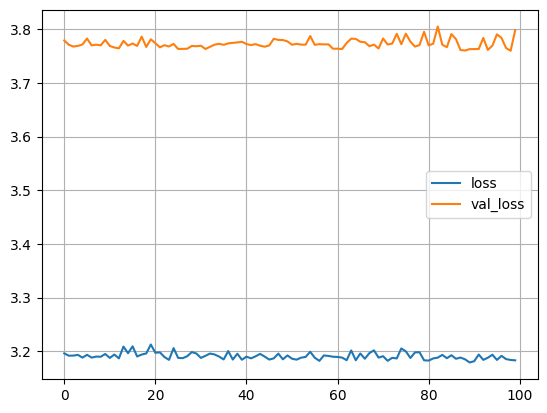

In [8]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
X_train_f = X_train.astype("float32").values
X_test_f  = X_test.astype("float32").values

full_norm = layers.Normalization()
full_norm.adapt(X_train_f)

dnn_full = keras.Sequential([
    full_norm,
    layers.Dense(64, activation="gelu"),
    layers.Dense(64, activation="gelu"),
    layers.Dense(1)
])
dnn_full.compile(optimizer=keras.optimizers.Adam(0.001), loss="mae", metrics=["mse"])

history_full = dnn_full.fit(X_train_f, y_train_f, validation_split=0.2, epochs=100, verbose=0)
dnn_full.evaluate(X_test_f, y_test_f, verbose=0)

[1.6595807075500488, 5.381531715393066]

In [10]:
hp_mae, hp_mse = dnn_horsepower_model.evaluate(X_hp_test, y_test_f, verbose=0)
full_mae, full_mse = dnn_full.evaluate(X_test_f, y_test_f, verbose=0)

print(f"Horsepower-only  | MAE={hp_mae:.3f} MPG | MSE={hp_mse:.3f}")
print(f"Full features    | MAE={full_mae:.3f} MPG | MSE={full_mse:.3f}")

Horsepower-only  | MAE=2.762 MPG | MSE=12.182
Full features    | MAE=1.660 MPG | MSE=5.382


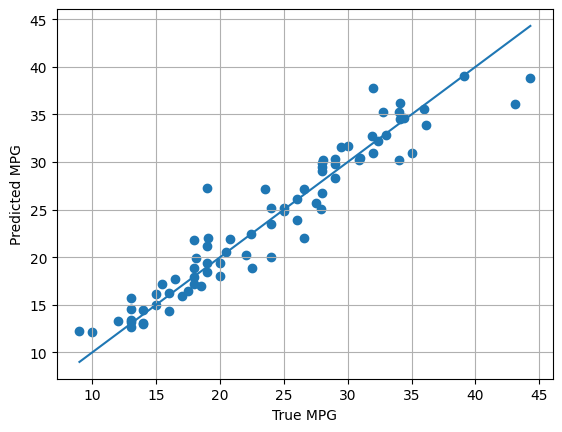

In [11]:
y_pred_full = dnn_full.predict(X_test_f, verbose=0).flatten()

plt.figure()
plt.scatter(y_test_f, y_pred_full)
plt.xlabel("True MPG")
plt.ylabel("Predicted MPG")
lims = [min(y_test_f.min(), y_pred_full.min()), max(y_test_f.max(), y_pred_full.max())]
plt.plot(lims, lims)
plt.grid(True)
plt.show()

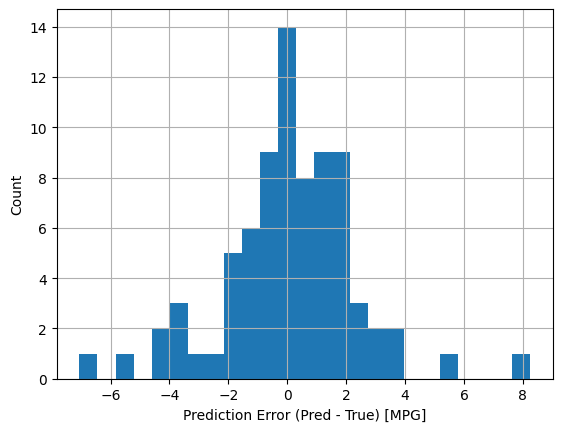

Error mean: 0.103359245  | Error std: 2.3175092


In [12]:
err = y_pred_full - y_test_f

plt.figure()
plt.hist(err, bins=25)
plt.xlabel("Prediction Error (Pred - True) [MPG]")
plt.ylabel("Count")
plt.grid(True)
plt.show()

print("Error mean:", err.mean(), " | Error std:", err.std())

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_f)
X_test_scaled  = scaler.transform(X_test_f)

lin = LinearRegression().fit(X_train_scaled, y_train_f)
pred_lin = lin.predict(X_test_scaled)

mae_lin = mean_absolute_error(y_test_f, pred_lin)
mse_lin = mean_squared_error(y_test_f, pred_lin)

print(f"LinearRegression | MAE={mae_lin:.3f} MPG | MSE={mse_lin:.3f}")

LinearRegression | MAE=2.389 MPG | MSE=10.172


In [14]:
cb = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history_full = dnn_full.fit(
    X_train_f, y_train_f,
    validation_split=0.2,
    epochs=500,
    verbose=0,
    callbacks=[cb]
)

In [15]:
# Re-evaluate + re-plot using the early-stopped model
full_mae_es, full_mse_es = dnn_full.evaluate(X_test_f, y_test_f, verbose=0)
print(f"Full features (EarlyStopping) | MAE={full_mae_es:.3f} MPG | MSE={full_mse_es:.3f}")

y_pred_full = dnn_full.predict(X_test_f, verbose=0).flatten()
err = y_pred_full - y_test_f

Full features (EarlyStopping) | MAE=1.690 MPG | MSE=5.513


Markdown notes for end of notebook (paste as markdown cell)

Results summary
	•	Trained three regressors on Auto MPG:
	1.	DNN (Horsepower only): single feature baseline using a normalization layer + 2 hidden layers.
	2.	DNN (Full features): same architecture but using all engineered input features.
	3.	Linear Regression (sklearn): strong tabular baseline with StandardScaler.
	•	Metrics used:
	•	MAE (MPG) as primary loss/interpretability metric.
	•	MSE reported as a secondary metric (more sensitive to outliers).

Key findings
	•	Horsepower-only vs Full features:
	•	The full-feature DNN should generally reduce MAE compared to horsepower-only because it has more signal (weight, cylinders, displacement, etc.).
	•	If the improvement is small, that suggests horsepower already explains much of the variance and the remaining features add limited incremental predictive power.
	•	DNN vs Linear Regression:
	•	On tabular datasets like Auto MPG, Linear Regression is a tough baseline.
	•	If the DNN does not clearly outperform Linear Regression, that’s normal and supports the idea that deep nets are not automatically better for tabular data.

Diagnostics / sanity checks
	•	Predicted vs True scatter:
	•	Points close to the diagonal indicate good calibration.
	•	Systematic curvature or “fan shapes” indicate missing non-linear structure or heteroscedasticity.
	•	Error histogram:
	•	Centered near 0 implies low bias.
	•	Long tails indicate outliers or hard-to-predict regions (e.g., unusual cars).

Overfitting control
	•	Used EarlyStopping on val_loss with restore_best_weights=True.
	•	This prevents training past the point where validation performance stops improving and reduces the chance of overfitting.

Final conclusion
	•	A DNN is a flexible curve-fitting model, but for structured tabular data:
	•	Start with simple baselines (Linear Regression / Trees).
	•	Use DNNs when there is evidence of complex interactions and enough data to justify the added complexity.
	•	Always validate with held-out test data and inspect prediction/error plots, not just loss curves.